In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("features_v1.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (2000, 31)
Columns: ['fare_pkr', 'trip_duration_min', 'driver_rating', 'surge_multiplier', 'hour', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'city_Karachi', 'city_Lahore', 'city_Peshawar', 'city_Quetta', 'vehicle_type_SUV', 'vehicle_type_Sedan', 'vehicle_type_Van', 'weather_Foggy', 'weather_Rainy', 'weather_Unknown', 'weather_Windy', 'effective_fare', 'fare_per_min', 'is_peak_hour', 'is_night_ride', 'is_high_surge', 'fare_efficiency']


,fare_pkr,trip_duration_min,driver_rating,surge_multiplier,hour,day_of_week,month,quarter,is_weekend,is_holiday,...,weather_Foggy,weather_Rainy,weather_Unknown,weather_Windy,effective_fare,fare_per_min,is_peak_hour,is_night_ride,is_high_surge,fare_efficiency
0,411.86,11.2,4.0,1.0,0,6,1,1,1,0,...,0,1,0,0,411.86,36.7732,0,1,0,411.86
1,664.70,21.6,4.2,1.0,6,6,1,1,1,0,...,0,0,0,0,664.70,30.7731,0,0,0,664.70
2,576.36,33.3,4.3,1.0,12,6,1,1,1,0,...,0,0,0,0,576.36,17.3081,0,0,0,576.36
3,673.60,33.7,4.2,1.0,18,6,1,1,1,0,...,1,0,0,0,673.60,19.9881,1,0,0,673.60
4,238.85,16.1,4.3,1.0,0,0,1,1,0,0,...,0,0,1,0,238.85,14.8354,0,1,0,238.85


In [3]:

import random
random.seed(42)
base_dates = []
for _, row in df.iterrows():
    month = int(row['month'])
    day_of_week = int(row['day_of_week'])   
    hour = int(row['hour'])
    import datetime
    # Start from first day of that month in 2024
    first_day = datetime.date(2024, month, 1)
    # Find first occurrence of that weekday
    days_ahead = (day_of_week - first_day.weekday()) % 7
    target_date = first_day + datetime.timedelta(days=days_ahead)
    dt_str = f"{target_date} {hour:02d}:00:00"
    base_dates.append(dt_str)

df['timestamp'] = pd.to_datetime(base_dates)
print("Timestamp column created!")
print(df[['timestamp', 'hour', 'day_of_week', 'month']].head(10))

Timestamp column created!
            timestamp  hour  day_of_week  month
0 2024-01-07 00:00:00     0            6      1
1 2024-01-07 06:00:00     6            6      1
2 2024-01-07 12:00:00    12            6      1
3 2024-01-07 18:00:00    18            6      1
4 2024-01-01 00:00:00     0            0      1
5 2024-01-01 06:00:00     6            0      1
6 2024-01-01 12:00:00    12            0      1
7 2024-01-01 18:00:00    18            0      1
8 2024-01-02 00:00:00     0            1      1
9 2024-01-02 06:00:00     6            1      1


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['Month'] = df['timestamp'].dt.month

df['DayOfWeek'] = df['timestamp'].dt.dayofweek

df['Is_Weekend'] = df['timestamp'].dt.dayofweek >= 5

df['Hour_of_Day'] = df['timestamp'].dt.hour
df['Quarter'] = df['timestamp'].dt.quarter
df['Day_Name'] = df['timestamp'].dt.day_name()

print("Datetime features extracted successfully!")
print()
print(df[['timestamp', 'Month', 'DayOfWeek', 'Is_Weekend', 'Hour_of_Day', 'Day_Name']].head(10))

Datetime features extracted successfully!

            timestamp  Month  DayOfWeek  Is_Weekend  Hour_of_Day Day_Name
0 2024-01-07 00:00:00      1          6        True            0   Sunday
1 2024-01-07 06:00:00      1          6        True            6   Sunday
2 2024-01-07 12:00:00      1          6        True           12   Sunday
3 2024-01-07 18:00:00      1          6        True           18   Sunday
4 2024-01-01 00:00:00      1          0       False            0   Monday
5 2024-01-01 06:00:00      1          0       False            6   Monday
6 2024-01-01 12:00:00      1          0       False           12   Monday
7 2024-01-01 18:00:00      1          0       False           18   Monday
8 2024-01-02 00:00:00      1          1       False            0  Tuesday
9 2024-01-02 06:00:00      1          1       False            6  Tuesday


In [5]:
import datetime

pk_holidays_2024 = [
    datetime.date(2024, 2, 5),  
    datetime.date(2024, 3, 23), 
    datetime.date(2024, 4, 10), 
    datetime.date(2024, 4, 11),
    datetime.date(2024, 4, 12),
    datetime.date(2024, 6, 16), 
    datetime.date(2024, 6, 17),
    datetime.date(2024, 6, 18),
    datetime.date(2024, 8, 14),  
    datetime.date(2024, 9, 15), 
    datetime.date(2024, 11, 9),  
    datetime.date(2024, 12, 25), 
]

df['Is_Holiday'] = df['timestamp'].dt.date.apply(lambda d: d in pk_holidays_2024)

print("Holiday feature extracted!")
print(f"Total holiday rides: {df['Is_Holiday'].sum()} out of {len(df)}")
print()
print(df[['timestamp', 'Month', 'DayOfWeek', 'Is_Weekend', 'Is_Holiday']].head(10))

Holiday feature extracted!
Total holiday rides: 32 out of 2000

            timestamp  Month  DayOfWeek  Is_Weekend  Is_Holiday
0 2024-01-07 00:00:00      1          6        True       False
1 2024-01-07 06:00:00      1          6        True       False
2 2024-01-07 12:00:00      1          6        True       False
3 2024-01-07 18:00:00      1          6        True       False
4 2024-01-01 00:00:00      1          0       False       False
5 2024-01-01 06:00:00      1          0       False       False
6 2024-01-01 12:00:00      1          0       False       False
7 2024-01-01 18:00:00      1          0       False       False
8 2024-01-02 00:00:00      1          1       False       False
9 2024-01-02 06:00:00      1          1       False       False


In [6]:

def get_city(row):
    if row['city_Karachi'] == 1: return 'Karachi'
    elif row['city_Lahore'] == 1: return 'Lahore'
    elif row['city_Peshawar'] == 1: return 'Peshawar'
    elif row['city_Quetta'] == 1: return 'Quetta'
    else: return 'Other'

def get_vehicle(row):
    if row['vehicle_type_SUV'] == 1: return 'SUV'
    elif row['vehicle_type_Sedan'] == 1: return 'Sedan'
    elif row['vehicle_type_Van'] == 1: return 'Van'
    else: return 'Other'

def get_weather(row):
    if row['weather_Foggy'] == 1: return 'Foggy'
    elif row['weather_Rainy'] == 1: return 'Rainy'
    elif row['weather_Unknown'] == 1: return 'Unknown'
    elif row['weather_Windy'] == 1: return 'Windy'
    else: return 'Clear'

df['City_Raw'] = df.apply(get_city, axis=1)
df['Vehicle_Raw'] = df.apply(get_vehicle, axis=1)
df['Weather_Raw'] = df.apply(get_weather, axis=1)

print("Raw categorical columns reconstructed:")
print(df[['City_Raw', 'Vehicle_Raw', 'Weather_Raw']].value_counts().head(10))

Raw categorical columns reconstructed:
City_Raw  Vehicle_Raw  Weather_Raw
Lahore    Other        Clear          113
Karachi   Other        Clear           89
Peshawar  Other        Clear           88
Other     Other        Clear           83
Quetta    Other        Clear           83
Peshawar  Sedan        Clear           72
Karachi   Sedan        Clear           67
Lahore    Sedan        Clear           65
Quetta    Sedan        Clear           63
          SUV          Clear           63
Name: count, dtype: int64


In [7]:
df_encoded = pd.get_dummies(df[['City_Raw', 'Vehicle_Raw', 'Weather_Raw']],
                             drop_first=True,
                             dtype=int)

print("One-Hot Encoded columns (drop_first=True):")
print(df_encoded.columns.tolist())
print()
print("Shape:", df_encoded.shape)
print()
print("Sample:")
df_encoded.head()

One-Hot Encoded columns (drop_first=True):
['City_Raw_Lahore', 'City_Raw_Other', 'City_Raw_Peshawar', 'City_Raw_Quetta', 'Vehicle_Raw_SUV', 'Vehicle_Raw_Sedan', 'Vehicle_Raw_Van', 'Weather_Raw_Foggy', 'Weather_Raw_Rainy', 'Weather_Raw_Unknown', 'Weather_Raw_Windy']

Shape: (2000, 11)

Sample:


,City_Raw_Lahore,City_Raw_Other,City_Raw_Peshawar,City_Raw_Quetta,Vehicle_Raw_SUV,Vehicle_Raw_Sedan,Vehicle_Raw_Van,Weather_Raw_Foggy,Weather_Raw_Rainy,Weather_Raw_Unknown,Weather_Raw_Windy
0,0,0,1,0,0,1,0,0,1,0,0
1,0,0,0,1,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,1,0,0,0
4,0,0,0,1,0,1,0,0,0,1,0


In [8]:
base_features = ['fare_pkr', 'trip_duration_min', 'driver_rating',
                 'surge_multiplier', 'effective_fare', 'fare_per_min',
                 'fare_efficiency']

datetime_features_df = pd.DataFrame({
    'Month': df['Month'].astype(int),
    'DayOfWeek': df['DayOfWeek'].astype(int),
    'Hour_of_Day': df['Hour_of_Day'].astype(int),
    'Quarter': df['Quarter'].astype(int),
    'Is_Weekend': df['Is_Weekend'].astype(int),
    'Is_Holiday': df['Is_Holiday'].astype(int),
})

df_final = pd.concat([
    df[base_features].reset_index(drop=True),
    datetime_features_df.reset_index(drop=True),
    df_encoded.reset_index(drop=True),
    df[['is_peak_hour', 'is_night_ride', 'is_high_surge',
        'hour_sin', 'hour_cos', 'month_sin', 'month_cos']].reset_index(drop=True)
], axis=1)

print("Final model-ready dataset:")
print("Shape:", df_final.shape)
print("Columns:", list(df_final.columns))
print()
df_final.head()

Final model-ready dataset:
Shape: (2000, 31)
Columns: ['fare_pkr', 'trip_duration_min', 'driver_rating', 'surge_multiplier', 'effective_fare', 'fare_per_min', 'fare_efficiency', 'Month', 'DayOfWeek', 'Hour_of_Day', 'Quarter', 'Is_Weekend', 'Is_Holiday', 'City_Raw_Lahore', 'City_Raw_Other', 'City_Raw_Peshawar', 'City_Raw_Quetta', 'Vehicle_Raw_SUV', 'Vehicle_Raw_Sedan', 'Vehicle_Raw_Van', 'Weather_Raw_Foggy', 'Weather_Raw_Rainy', 'Weather_Raw_Unknown', 'Weather_Raw_Windy', 'is_peak_hour', 'is_night_ride', 'is_high_surge', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']



,fare_pkr,trip_duration_min,driver_rating,surge_multiplier,effective_fare,fare_per_min,fare_efficiency,Month,DayOfWeek,Hour_of_Day,...,Weather_Raw_Rainy,Weather_Raw_Unknown,Weather_Raw_Windy,is_peak_hour,is_night_ride,is_high_surge,hour_sin,hour_cos,month_sin,month_cos
0,411.86,11.2,4.0,1.0,411.86,36.7732,411.86,1,6,0,...,1,0,0,0,1,0,0.0,1.0,0.5,0.866025
1,664.70,21.6,4.2,1.0,664.70,30.7731,664.70,1,6,6,...,0,0,0,0,0,0,1.0,0.0,0.5,0.866025
2,576.36,33.3,4.3,1.0,576.36,17.3081,576.36,1,6,12,...,0,0,0,0,0,0,0.0,-1.0,0.5,0.866025
3,673.60,33.7,4.2,1.0,673.60,19.9881,673.60,1,6,18,...,0,0,0,1,0,0,-1.0,-0.0,0.5,0.866025
4,238.85,16.1,4.3,1.0,238.85,14.8354,238.85,1,0,0,...,0,1,0,0,1,0,0.0,1.0,0.5,0.866025


In [9]:

print("Null values:", df_final.isnull().sum().sum())
print("All numeric?", all(df_final.dtypes != 'object'))
print()
print("Data types:")
print(df_final.dtypes)

Null values: 0
All numeric? True

Data types:
fare_pkr               float64
trip_duration_min      float64
driver_rating          float64
surge_multiplier       float64
effective_fare         float64
fare_per_min           float64
fare_efficiency        float64
Month                    int64
DayOfWeek                int64
Hour_of_Day              int64
Quarter                  int64
Is_Weekend               int64
Is_Holiday               int64
City_Raw_Lahore          int64
City_Raw_Other           int64
City_Raw_Peshawar        int64
City_Raw_Quetta          int64
Vehicle_Raw_SUV          int64
Vehicle_Raw_Sedan        int64
Vehicle_Raw_Van          int64
Weather_Raw_Foggy        int64
Weather_Raw_Rainy        int64
Weather_Raw_Unknown      int64
Weather_Raw_Windy        int64
is_peak_hour             int64
is_night_ride            int64
is_high_surge            int64
hour_sin               float64
hour_cos               float64
month_sin              float64
month_cos              f

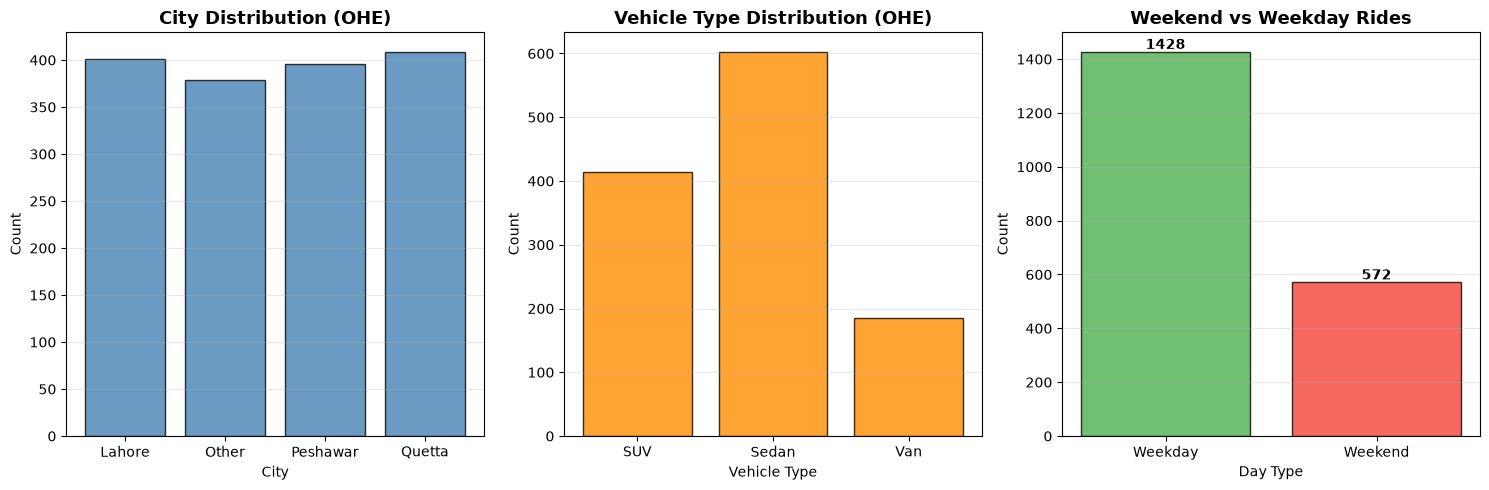

Plot saved!


In [10]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


city_cols_new = [c for c in df_encoded.columns if 'City_Raw' in c]
city_sums = df_encoded[city_cols_new].sum()
axes[0].bar(city_sums.index.str.replace('City_Raw_', ''), city_sums.values,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('City Distribution (OHE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3, axis='y')


veh_cols_new = [c for c in df_encoded.columns if 'Vehicle_Raw' in c]
veh_sums = df_encoded[veh_cols_new].sum()
axes[1].bar(veh_sums.index.str.replace('Vehicle_Raw_', ''), veh_sums.values,
            color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title('Vehicle Type Distribution (OHE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vehicle Type')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3, axis='y')


weekend_counts = df['Is_Weekend'].value_counts()
axes[2].bar(['Weekday', 'Weekend'], weekend_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black', alpha=0.8)
axes[2].set_title('Weekend vs Weekday Rides', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Day Type')
axes[2].set_ylabel('Count')
for i, v in enumerate(weekend_counts.values):
    axes[2].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('encoding_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [11]:
df_final.to_csv("model_ready_features.csv", index=False)

import os
size = os.path.getsize("model_ready_features.csv") / 1024
print(f"Exported: model_ready_features.csv ({size:.1f} KB)")
print(f"Shape: {df_final.shape}")
print(f"Total features: {df_final.shape[1]}")

Exported: model_ready_features.csv (208.9 KB)
Shape: (2000, 31)
Total features: 31
